In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [10]:
housing = fetch_california_housing()

data = pd.DataFrame(housing.data,columns=housing.feature_names)
data["Price"] = housing.target

In [13]:
X = data[['AveRooms']].values
y = data['Price'].values

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.8,
    random_state=42
)

In [63]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [64]:
w = 0
b = 0

learning_rate = 0.06
epochs = 1000

cost_history = []

n = len(X_train_scaled)

for i in range(epochs):
    y_pred = w * X_train_scaled.flatten() + b

    cost = (1/(2*n)) * np.sum((y_pred - y_train) ** 2)
    cost_history.append(cost)

    dw = (1/n) * np.sum((y_pred - y_train) * X_train_scaled.flatten())
    db = (1/n) * np.sum(y_pred - y_train)

    w = w - learning_rate * dw
    b = b - learning_rate * db

    if i % 100 == 0:
        print(f"Epoch {i}, Cost = {cost:.4f}")

y_pred_gd = w * X_test_scaled.flatten() + b

Epoch 0, Cost = 2.8193
Epoch 100, Cost = 0.6598
Epoch 200, Cost = 0.6598
Epoch 300, Cost = 0.6598
Epoch 400, Cost = 0.6598
Epoch 500, Cost = 0.6598
Epoch 600, Cost = 0.6598
Epoch 700, Cost = 0.6598
Epoch 800, Cost = 0.6598
Epoch 900, Cost = 0.6598


In [65]:
print("Gradient Descent")
print("----------------")
print("Weight:", w)
print("Bias:", b)
print("MSE:", mean_squared_error(y_test, y_pred_gd))
print("R2 Score:", r2_score(y_test, y_pred_gd))

Gradient Descent
----------------
Weight: 0.16220815795772262
Bias: 2.071855610465113
MSE: 1.298859703833562
R2 Score: 0.021897063437695596


In [66]:
X_train_ne = np.c_[np.ones((len(X_train), 1)), X_train]
X_test_ne = np.c_[np.ones((len(X_test), 1)), X_test]

theta = np.linalg.inv(X_train_ne.T @ X_train_ne) @ X_train_ne.T @ y_train

y_pred_ne = X_test_ne @ theta

In [67]:
print("\nNormal Equation")
print("------------------")
print("Intercept:", theta[0])
print("Slope:", theta[1])
print("MSE:", mean_squared_error(y_test, y_pred_ne))
print("R2 Score:", r2_score(y_test, y_pred_ne))


Normal Equation
------------------
Intercept: 1.7877830289254806
Slope: 0.051844714648327385
MSE: 1.2988597038335623
R2 Score: 0.021897063437695374


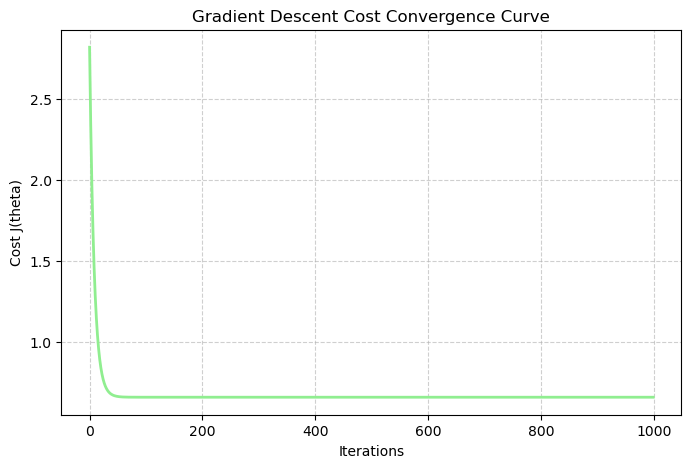

In [80]:
plt.figure(figsize=(8,5))

plt.plot(cost_history, color='lightgreen', linewidth=2)

plt.title('Gradient Descent Cost Convergence Curve')
plt.xlabel('Iterations')
plt.ylabel('Cost J(theta)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

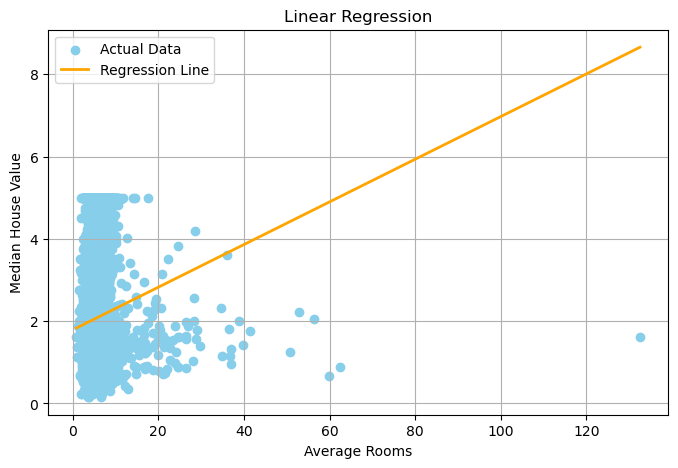

In [82]:
index = np.argsort(X_test.flatten())
plt.figure(figsize=(8,5))

plt.scatter(X_test, y_test, color='skyblue', label='Actual Data')

plt.plot(
    X_test.flatten()[index],
    y_pred_ne[index],
    color='orange',
    linewidth=2,
    label='Regression Line'
)
plt.title("Linear Regression")
plt.xlabel("Average Rooms")
plt.ylabel("Median House Value")
plt.legend()
plt.grid(True)

plt.show()